Clase 5 Foro Obligatorio
Tomaremos un conjunto de datos que nos interese trabajar y mediante la implementación de los algoritmos Árbol de Decisión y K-NN, evaluaremos y compararemos la precisión de los clasificadores generados. 

Tomamos de Kaggle un dataset para predicción de Infartos.

Dataset
Stroke Prediction Dataset
11 clinical features for predicting stroke events

Context
According to the World Health Organization (WHO) stroke is the 2nd leading cause of death globally, responsible for approximately 11% of total deaths. This dataset is used to predict whether a patient is likely to get stroke based on the input parameters like gender, age, various diseases, and smoking status. Each row in the data provides relavant information about the patient.

Attribute Information
1) id: unique identifier
2) gender: "Male", "Female" or "Other"
3) age: age of the patient
4) hypertension: 0 if the patient doesn't have hypertension, 1 if the patient has hypertension
5) heart_disease: 0 if the patient doesn't have any heart diseases, 1 if the patient has a heart disease
6) ever_married: "No" or "Yes"
7) work_type: "children", "Govt_jov", "Never_worked", "Private" or "Self-employed"
8) Residence_type: "Rural" or "Urban"
9) avg_glucose_level: average glucose level in blood
10) bmi: body mass index
11) smoking_status: "formerly smoked", "never smoked", "smokes" or "Unknown"
12) stroke: 1 if the patient had a stroke or 0 if not
*Note: "Unknown" in smoking_status means that the information is unavailable for this patient


In [177]:
# importación de librerías

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.impute import SimpleImputer

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

In [163]:
# Importación de Archivo CSV (Comma-Separated Values)

datos_csv = pd.read_csv(r"C:\Users\orlan\OneDrive\Documents\Tecnicatura\2A1C - Aprendizaje Automatico\Semana 5\healthcare-dataset-stroke-data.csv", encoding= "ISO-8859-1")
print("Archivo CSV")
datos_csv.head()

Archivo CSV


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [186]:
# Vamos a eliminar las columnas que son menos relevantes en un análisis preliminar
# id, ever_married, work_type, Residence_type

X = datos_csv.drop(["id", "gender", "ever_married", "work_type", "Residence_type","bmi","smoking_status", "stroke"], axis=1)
y = datos_csv["stroke"]

#saqué gender y smoking status, y tuve que sacar variables categóricas

# Tenemos columnas numéricas, categóricas y binarias
# Vamos a identificar las tres, y realizar one-hot encoding a las categóricas
# Con SelectKBest identificamos las siguientes 4 variables como más relevantes: age, heart_disease, avg_glucose_level y hypertension

numericas=["age","avg_glucose_level"]
# categoricas=[] #gender
binarias=["hypertension","heart_disease"]

X_numericas = X[numericas]

# One_hot encoding a las categóricas

#X_categoricas = pd.get_dummies(X[categoricas],drop_first=True)

X_binarias = X[binarias]

X_final = pd.concat([X_numericas,X_binarias], axis=1) # X_categoricas,

X_final.head()

# quedó desordenado el código debido a las idas y vueltas hasta que encontré las categorías con las que finalmente iba a trabajar


,age,avg_glucose_level,hypertension,heart_disease
0,67.0,228.69,0,1
1,61.0,202.21,0,0
2,80.0,105.92,0,1
3,49.0,171.23,0,0
4,79.0,174.12,1,0


In [187]:
# Verificacion de datos faltantes

print(X_final.isnull().sum())

age                  0
avg_glucose_level    0
hypertension         0
heart_disease        0
dtype: int64


In [188]:
# Trabajo con filas NaN
# La columna bmi tiene 201 NaN, las demás están bien.
# Hay varias opciones, eliminar las filas que tienen estos valores, o reemplazarlos con sus medias o medianas.
# Vamos a imputar medianas donde hay NaNs, leo que suele ser una buena opción, habría que validarlo en algún momento.

# Al sacar la columna bmi, ya no es necesario trabajar con NaN

# imputer = SimpleImputer(strategy="median")
# X_final[["bmi"]] = imputer.fit_transform(X_final[["bmi"]])
# print(X_final.isnull().sum())


In [189]:
# División de entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.3, random_state=42)

# Escalado de variables

scaler = StandardScaler()
X_train[numericas] = scaler.fit_transform(X_train[numericas])
X_test[numericas] = scaler.transform(X_test[numericas])


In [190]:
# Modelo KNN
#Vamos a buscar el mejor K

param_grid = {
    'n_neighbors': range(1,21)}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)
print(grid.best_params_)

{'n_neighbors': 6}


In [191]:
# Esto es insuficiente para mejorar los resultados
# Sigue no reconociendo una de las clases

param_grid = {
    'n_neighbors': range(1,15),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='f1_macro'
)

grid.fit(X_train, y_train)

results_knn = pd.DataFrame(grid.cv_results_)

results_knn = results_knn.sort_values(
    by='mean_test_score',
    ascending=False
)
print("Mejores Resultados KNN:")
print(results_knn[['param_n_neighbors','param_weights','param_metric','mean_test_score']].head())


Mejores Resultados KNN:
    param_n_neighbors param_weights param_metric  mean_test_score
5                   3      distance    euclidean         0.539107
35                  4      distance    manhattan         0.537295
28                  1       uniform    manhattan         0.536901
31                  2      distance    manhattan         0.536901
29                  1      distance    manhattan         0.536901


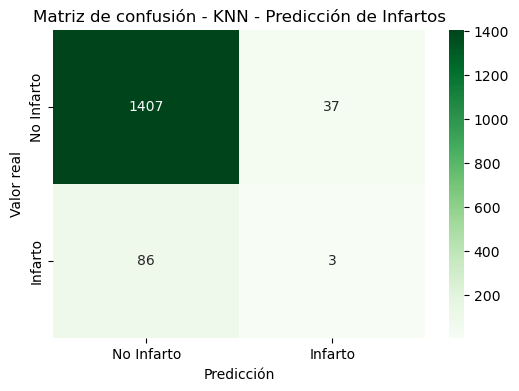

Métricas KNN:
              precision    recall  f1-score   support

  No Infarto       0.94      0.97      0.96      1444
     Infarto       0.07      0.03      0.05        89

    accuracy                           0.92      1533
   macro avg       0.51      0.50      0.50      1533
weighted avg       0.89      0.92      0.91      1533



In [195]:
# Modelo KNN

knn = KNeighborsClassifier(n_neighbors=3, weights='distance', metric='euclidean')

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

cm_KNN_Infartos = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6,4))
sns.heatmap(cm_KNN_Infartos, annot=True, fmt="d", cmap="Greens",xticklabels=["No Infarto", "Infarto"],yticklabels=["No Infarto", "Infarto"])
plt.title("Matriz de confusión - KNN - Predicción de Infartos")
plt.ylabel("Valor real")
plt.xlabel("Predicción")
print()
plt.show()

print("Métricas KNN:")
print(classification_report(y_test, y_pred_knn,target_names=["No Infarto", "Infarto"]))



In [193]:
# Modelo Arbol de Decisión

# Como nuevamente casi no reconoce una de las clases voy a buscar los mejores hiperparametros

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': range(1,11),
    'min_samples_split': range(2,11),
    'min_samples_leaf': range(1,6)
}

grid_tree = GridSearchCV(
    DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_tree.fit(X_train, y_train)

results_AdD = pd.DataFrame(grid_tree.cv_results_)
results_AdD = results.sort_values(by='mean_test_score',ascending=False)
print("\nMejores Resultados Arbol de Decisión:")
print(results_AdD[['param_criterion','param_max_depth','param_min_samples_split','param_min_samples_leaf','mean_test_score']].head())



Mejores Resultados Arbol de Decisión:
    param_criterion  param_max_depth  param_min_samples_split  \
405            gini               10                        2   
591         entropy                4                        8   
585         entropy                4                        2   
586         entropy                4                        3   
590         entropy                4                        7   

     param_min_samples_leaf  mean_test_score  
405                       1         0.549229  
591                       1         0.548819  
585                       1         0.548819  
586                       1         0.548819  
590                       1         0.548819  


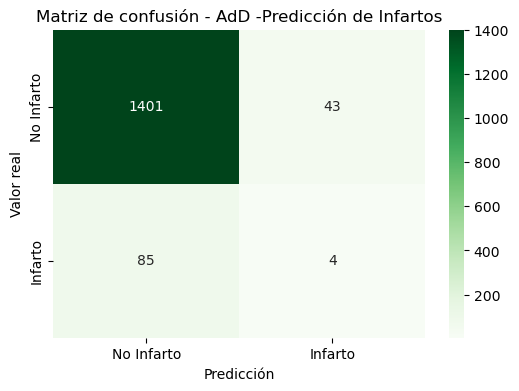

Métricas Árbol de Decisión:
              precision    recall  f1-score   support

  No Infarto       0.94      0.97      0.96      1444
     Infarto       0.09      0.04      0.06        89

    accuracy                           0.92      1533
   macro avg       0.51      0.51      0.51      1533
weighted avg       0.89      0.92      0.90      1533



In [196]:


tree = DecisionTreeClassifier(criterion='gini', max_depth=10, min_samples_split=2,min_samples_leaf=1,random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

cm_AdD_Infartos = confusion_matrix(y_test, y_pred_tree)
plt.figure(figsize=(6,4))
sns.heatmap(cm_AdD_Infartos, annot=True, fmt="d", cmap="Greens",xticklabels=["No Infarto", "Infarto"],yticklabels=["No Infarto", "Infarto"])
plt.title("Matriz de confusión - AdD -Predicción de Infartos")
plt.ylabel("Valor real")
plt.xlabel("Predicción")
print()
plt.show()

print("Métricas Árbol de Decisión:")
print(classification_report(y_test, y_pred_tree,target_names=["No Infarto", "Infarto"]))

In [185]:
# SelectKBest
X_SelectKBest = datos_csv.drop([ "stroke"], axis=1)
y_SelectKBest = datos_csv["stroke"]

imputer = SimpleImputer(strategy="median")
X_SelectKBest[["bmi"]] = imputer.fit_transform(X_SelectKBest[["bmi"]])

X_encoded = pd.get_dummies(X_SelectKBest, drop_first=True)

selector = SelectKBest(score_func=f_classif,k=4)

X_new = selector.fit_transform(X_encoded, y_SelectKBest)
selected_features = X_encoded.columns[selector.get_support()]
print(selected_features)

scores = pd.DataFrame({
    'Variable': X_encoded.columns,
    'Score': selector.scores_
})

scores = scores.sort_values(
    by='Score',
    ascending=False
)

print(scores)

Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level'], dtype='object')
                          Variable       Score
1                              age  326.916568
3                    heart_disease   94.698406
4                avg_glucose_level   90.503870
2                     hypertension   84.953542
8                 ever_married_Yes   60.667230
12              work_type_children   36.184470
14  smoking_status_formerly smoked   21.376277
11         work_type_Self-employed   19.818466
5                              bmi    6.669168
13            Residence_type_Urban    1.220842
9           work_type_Never_worked    1.131609
10               work_type_Private    0.722016
6                      gender_Male    0.424625
16           smoking_status_smokes    0.408210
0                               id    0.208459
15     smoking_status_never smoked    0.087073
7                     gender_Other    0.051215


Aún con todo esto seguimos detectando muy pocos casos con infartos.
El desbalanceo es muy fuerte, y el modelo sigue favoreciendo la clase dominante No Infartos.
